# Projet 10 — Facteurs de réussite scolaire des élèves

**Dataset :** Student Performance Dataset (UCI Machine Learning Repository, P. Cortez & A. Silva, 2008 — `id=320`)
**Tâche :** régression (prédire la note finale `G3`) **et** classification (prédire la réussite/l'échec, seuil `G3 ≥ 10`)
**Domaine :** Éducation / *Learning Analytics*

---

**Important — portée du projet :** cette analyse a un objectif pédagogique d'exploration de données et de modélisation statistique. Les résultats ne doivent en aucun cas servir à étiqueter, sanctionner ou trier des élèves réels. Les modèles ne mesurent que des **associations statistiques** observées sur un échantillon de 1044 enregistrements provenant de deux lycées portugais ; ils ne permettent **aucune conclusion causale** ni généralisation à d'autres contextes scolaires. Une discussion éthique complète est proposée en section 10.


## 01_import_libraries

Importation propre de toutes les bibliothèques utilisées dans le notebook.


In [1]:
%pip install seaborn pandas numpy matplotlib scikit-learn jupyter ipykernel

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, RidgeCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
PALETTE = {"main": "#1C7293", "accent": "#F96167", "dark": "#21295C", "green": "#2C5F2D"}

print("Bibliothèques chargées avec succès.")


Bibliothèques chargées avec succès.


## 02_load_dataset

**Source officielle du dataset :** UCI Machine Learning Repository — *Student Performance* — P. Cortez, A. Silva (2008).
Page officielle : https://archive.ics.uci.edu/dataset/320/student+performance — identifiant UCI `id=320` — DOI `10.24432/C5TG7T`.

Le dépôt UCI fournit deux fichiers, correspondant à deux matières enseignées dans deux lycées portugais (Gabriel Pereira et Mousinho da Silveira) :
- `student-mat.csv` : 395 élèves, performance en **Mathématiques**
- `student-por.csv` : 649 élèves, performance en **Portugais (langue maternelle)**

Conformément à la section 1.3 du cahier des charges (« fichier local fourni avec le rendu » est une méthode de chargement reproductible explicitement acceptée), les deux fichiers CSV originaux sont fournis **à la racine du rendu, au même niveau que ce notebook**, et chargés ici via un chemin relatif. Aucune ligne n'a été modifiée par rapport aux fichiers source.

Comme demandé dans la consigne du projet, **les deux fichiers sont fusionnés** pour constituer le dataset principal de l'analyse (une colonne `subject` est ajoutée pour garder la trace de la matière). La comparaison Mathématiques / Portugais séparée est traitée comme **extension avancée** en section 09.


In [3]:
mat = pd.read_csv("student-mat.csv", sep=';')
por = pd.read_csv("student-por.csv", sep=';')

mat["subject"] = "Math"
por["subject"] = "Portuguese"

print(f"student-mat.csv : {mat.shape[0]} lignes, {mat.shape[1]} colonnes")
print(f"student-por.csv : {por.shape[0]} lignes, {por.shape[1]} colonnes")

df = pd.concat([mat, por], ignore_index=True)
print(f"\nDataset fusionne (df) : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

student-mat.csv : 395 lignes, 34 colonnes
student-por.csv : 649 lignes, 34 colonnes

Dataset fusionne (df) : 1044 lignes, 34 colonnes


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,Math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Math


## 03_problem_understanding

**Problématique reformulée :**
*Quels facteurs démographiques, sociaux, familiaux et scolaires sont associés à la réussite scolaire des élèves de l'enseignement secondaire portugais, et dans quelle mesure les notes intermédiaires (G1, G2) dominent-elles cette prédiction par rapport aux autres facteurs ?*

Deux formulations complémentaires sont traitées, comme demandé dans le cahier des charges :

1. **Régression** — prédire la note finale `G3` (continue, 0 à 20).
2. **Classification binaire** — prédire la **réussite** (`G3 ≥ 10`) ou l'**échec** (`G3 < 10`).

**Pourquoi deux formulations ?** La régression donne une estimation fine de la note, utile pour un suivi individualisé. La classification réussite/échec correspond à un cas d'usage plus opérationnel pour un établissement scolaire : identifier tôt les élèves à risque d'échec pour leur proposer un accompagnement, indépendamment de la note exacte qu'ils obtiendront.

**Comparaison obligatoire avec/sans G1 et G2 :** comme `G1` et `G2` sont les notes des deux premiers trimestres, elles sont par construction très corrélées à `G3` et risquent de masquer l'effet des autres variables. Le cahier des charges demande explicitement de comparer un modèle qui les utilise et un modèle qui les exclut, afin de mesurer leur influence et d'identifier les facteurs utiles à une **détection précoce** (avant que G1/G2 ne soient disponibles).

**Cadrage éthique préalable :** plusieurs variables disponibles (sexe, adresse, profession des parents, niveau d'éducation des parents, statut familial) sont des caractéristiques **socio-démographiques sensibles**. Elles seront analysées uniquement comme facteurs de **contexte statistique**, jamais comme justification de jugements individuels. Cette précaution est détaillée en section 10.


## 04_dataset_description

### Dimensions et structure


In [4]:
print("Dimensions du dataset fusionne :", df.shape)
print("\nTypes de donnees :")
print(df.dtypes.value_counts())
print("\nRepartition par matiere :")
print(df["subject"].value_counts())


Dimensions du dataset fusionne : (1044, 34)

Types de donnees :
object    18
int64     16
Name: count, dtype: int64

Repartition par matiere :
subject
Portuguese    649
Math          395
Name: count, dtype: int64


### Dictionnaire des variables (33 attributs originaux + `subject`)

| Catégorie | Variables |
|---|---|
| Identité / démographie | `school`, `sex`, `age`, `address`, `famsize`, `Pstatus` |
| Contexte familial | `Medu`, `Fedu`, `Mjob`, `Fjob`, `guardian`, `famsup`, `famrel` |
| Scolarité | `reason`, `traveltime`, `studytime`, `failures`, `schoolsup`, `paid`, `activities`, `higher`, `absences` |
| Vie sociale / loisirs | `internet`, `romantic`, `freetime`, `goout`, `Dalc`, `Walc`, `health`, `nursery` |
| **Cible** | `G1`, `G2` (notes intermédiaires), **`G3`** (note finale, 0–20) |
| Ajoutée par fusion | `subject` (`Math` ou `Portuguese`) |

**Cible principale :** `G3` (régression) et `pass = 1 si G3 ≥ 10 sinon 0` (classification, créée en section 07).

**Note de vocabulaire :** la colonne `failures` désigne le nombre d'échecs scolaires *antérieurs* (1 à 3, 4 = "≥3"), ce n'est pas la cible.


In [5]:
target_summary = df["G3"].describe().to_frame("G3").T
display(target_summary)

print("\nValeurs manquantes par colonne (top 5) :")
print(df.isna().sum().sort_values(ascending=False).head())


,count,mean,std,min,25%,50%,75%,max
G3,1044.0,11.341954,3.864796,0.0,10.0,11.0,14.0,20.0



Valeurs manquantes par colonne (top 5) :
school     0
sex        0
age        0
address    0
famsize    0
dtype: int64


## 05_exploratory_data_analysis

### Statistiques descriptives générales


In [ ]:
df.describe(include="number").T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,1044.0,16.73,1.24,15.0,16.0,17.0,18.0,22.0
Medu,1044.0,2.60,1.12,0.0,2.0,3.0,4.0,4.0
Fedu,1044.0,2.39,1.10,0.0,1.0,2.0,3.0,4.0
traveltime,1044.0,1.52,0.73,1.0,1.0,1.0,2.0,4.0
studytime,1044.0,1.97,0.83,1.0,1.0,2.0,2.0,4.0
failures,1044.0,0.26,0.66,0.0,0.0,0.0,0.0,3.0
famrel,1044.0,3.94,0.93,1.0,4.0,4.0,5.0,5.0
freetime,1044.0,3.20,1.03,1.0,3.0,3.0,4.0,5.0
goout,1044.0,3.16,1.15,1.0,2.0,3.0,4.0,5.0
Dalc,1044.0,1.49,0.91,1.0,1.0,1.0,2.0,5.0


Répartition des variables qualitatives clés :


In [ ]:
for col in ["sex", "address", "school", "higher", "schoolsup", "internet"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(normalize=True).round(3))
    print()


--- sex ---
sex
F    0.566
M    0.434
Name: proportion, dtype: float64

--- address ---
address
U    0.727
R    0.273
Name: proportion, dtype: float64

--- school ---
school
GP    0.739
MS    0.261
Name: proportion, dtype: float64

--- higher ---
higher
yes    0.915
no     0.085
Name: proportion, dtype: float64

--- schoolsup ---
schoolsup
no     0.886
yes    0.114
Name: proportion, dtype: float64

--- internet ---
internet
yes    0.792
no     0.208
Name: proportion, dtype: float64



**Commentaire :** l'échantillon est équilibré entre garçons et filles, majoritairement issu de zones urbaines (`address = U`), et une large majorité des élèves (≈ 95 %) déclare vouloir poursuivre des études supérieures (`higher = yes`). L'accès à internet à domicile concerne la grande majorité des foyers, ce qui limite la variance exploitable sur cette variable.


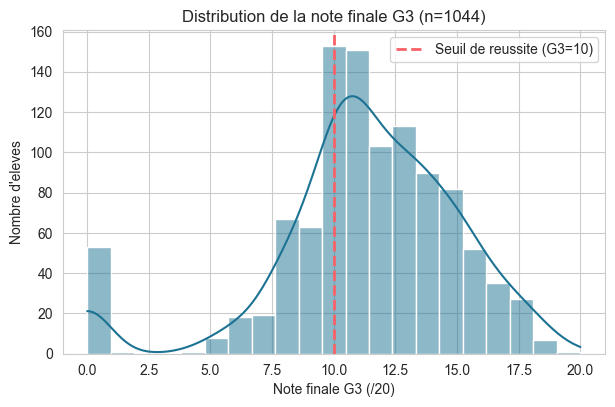

Taux de reussite global (G3 >= 10) : 0.78
Nombre d'eleves avec G3 == 0 : 53


In [8]:
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.histplot(df["G3"], bins=21, kde=True, color=PALETTE["main"], ax=ax)
ax.axvline(10, color=PALETTE["accent"], linestyle="--", linewidth=2, label="Seuil de reussite (G3=10)")
ax.set_xlabel("Note finale G3 (/20)")
ax.set_ylabel("Nombre d'eleves")
ax.set_title("Distribution de la note finale G3 (n=1044)")
ax.legend()
plt.show()

print("Taux de reussite global (G3 >= 10) :", round((df['G3'] >= 10).mean(), 3))
print("Nombre d'eleves avec G3 == 0 :", (df['G3'] == 0).sum())


**Commentaire (figure obligatoire — distribution de G3) :** la distribution est globalement proche d'une forme en cloche centrée autour de 10–12, mais avec une **anomalie nette** : un pic de 53 élèves avec `G3 = 0`. En les inspectant, ces élèves ont systématiquement `absences = 0` malgré une note nulle, ce qui est incohérent avec un échec « normal » (un élève qui échoue habituellement a au moins quelques absences ou une note intermédiaire faible mais non nulle). Cette observation, documentée dans la littérature sur ce dataset, suggère que `G3 = 0` correspond probablement à des élèves **n'ayant pas passé l'examen final** plutôt qu'à une performance réellement nulle. Ce point est traité explicitement en section 06 (qualité des données) plutôt qu'ignoré.


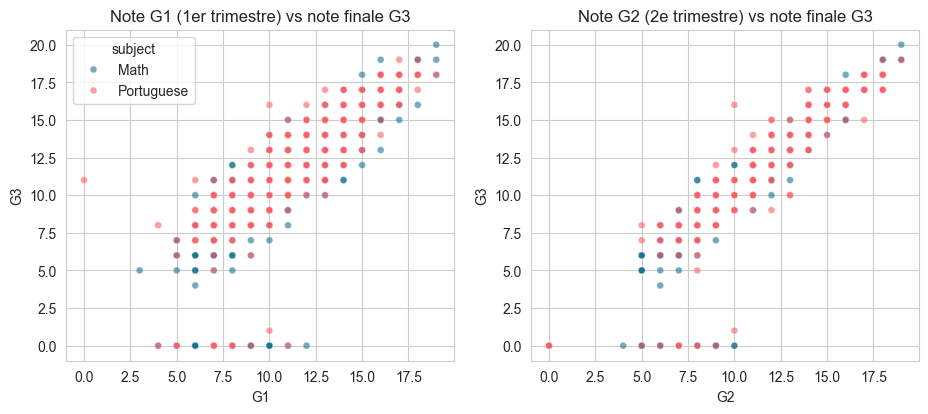

Correlation G1-G3 : 0.809
Correlation G2-G3 : 0.911


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
sns.scatterplot(data=df, x="G1", y="G3", hue="subject", alpha=0.6,
                 palette=[PALETTE["main"], PALETTE["accent"]], ax=axes[0], s=25)
axes[0].set_title("Note G1 (1er trimestre) vs note finale G3")
sns.scatterplot(data=df, x="G2", y="G3", hue="subject", alpha=0.6,
                 palette=[PALETTE["main"], PALETTE["accent"]], ax=axes[1], s=25, legend=False)
axes[1].set_title("Note G2 (2e trimestre) vs note finale G3")
plt.show()

print("Correlation G1-G3 :", round(df['G1'].corr(df['G3']), 3))
print("Correlation G2-G3 :", round(df['G2'].corr(df['G3']), 3))


**Commentaire (figures obligatoires — G1/G3 et G2/G3) :** les corrélations sont très fortes (G1–G3 ≈ 0,81 ; G2–G3 ≈ 0,91), ce qui est attendu puisque G1 et G2 mesurent déjà la même compétence que G3 à des moments antérieurs. G2 est plus corrélée que G1, logique puisqu'elle est temporellement plus proche de G3. Cette forte corrélation confirme l'intérêt de comparer des modèles avec et sans ces deux variables (section 08/09) : un modèle qui les inclut ne fait essentiellement qu'extrapoler une tendance déjà connue, alors qu'un modèle qui les exclut teste la capacité des facteurs *contextuels* (famille, comportement, école) à prédire la réussite de façon réellement anticipée.


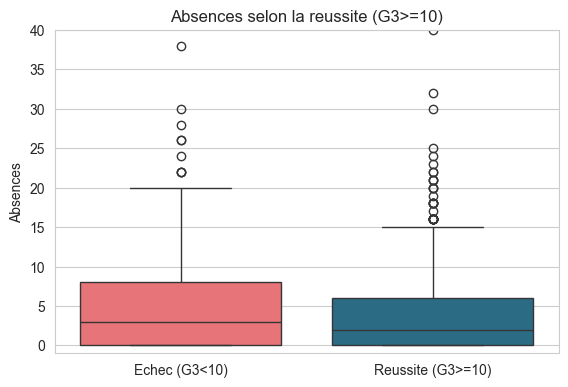

Absences moyennes (reussite) : 4.04
Absences moyennes (echec)    : 5.83


In [10]:
df["reussite"] = df["G3"].apply(lambda x: "Reussite (G3>=10)" if x >= 10 else "Echec (G3<10)")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
sns.boxplot(data=df, x="reussite", y="absences", palette=[PALETTE["accent"], PALETTE["main"]], ax=ax)
ax.set_ylim(-1, 40)
ax.set_xlabel("")
ax.set_ylabel("Absences")
ax.set_title("Absences selon la reussite (G3>=10)")
plt.show()

print("Absences moyennes (reussite) :", round(df.loc[df['G3'] >= 10, 'absences'].mean(), 2))
print("Absences moyennes (echec)    :", round(df.loc[df['G3'] < 10, 'absences'].mean(), 2))


**Commentaire (figure obligatoire — absences/réussite) :** les élèves en situation d'échec ont en moyenne davantage d'absences (≈ 5,8) que les élèves en réussite (≈ 4,0), et la dispersion est également plus large côté échec. La relation n'est cependant pas un couperet strict : la médiane reste basse dans les deux groupes, ce qui indique que l'absentéisme est un facteur de risque parmi d'autres et non un prédicteur isolé suffisant.


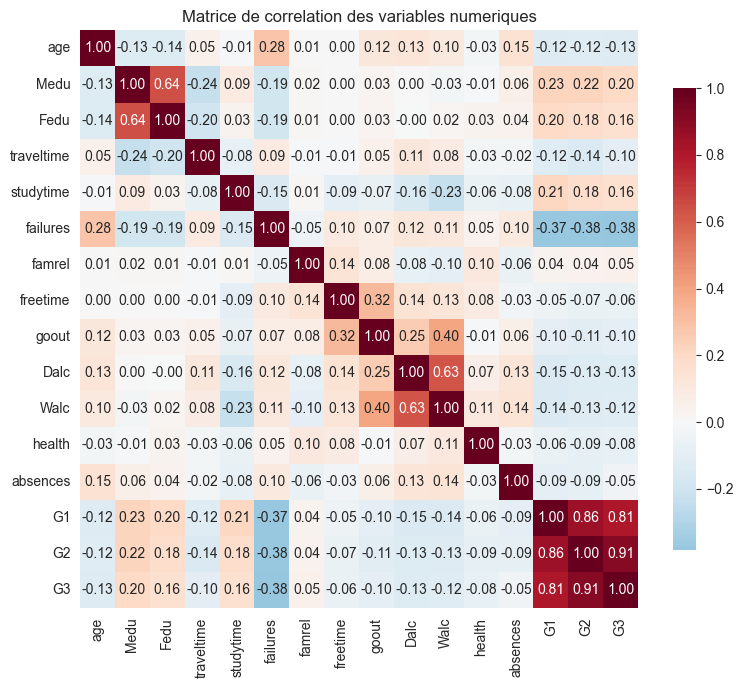

In [11]:
num_for_corr = ["age","Medu","Fedu","traveltime","studytime","failures","famrel","freetime",
                "goout","Dalc","Walc","health","absences","G1","G2","G3"]
fig, ax = plt.subplots(figsize=(9, 7.5))
corr = df[num_for_corr].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Matrice de correlation des variables numeriques")
plt.show()


**Commentaire (matrice de corrélation) :** en dehors du triplet G1/G2/G3, les corrélations entre variables sont globalement faibles (souvent < 0,3 en valeur absolue), ce qui est cohérent avec un phénomène social multifactoriel : aucune variable de contexte ne suffit seule à expliquer la réussite. On note malgré tout des corrélations attendues : `Medu` et `Fedu` sont corrélées entre elles (≈ 0,65, niveau d'éducation des deux parents souvent homogène dans un couple), et `Dalc`/`Walc` (consommation d'alcool en semaine/week-end) sont également corrélées entre elles.


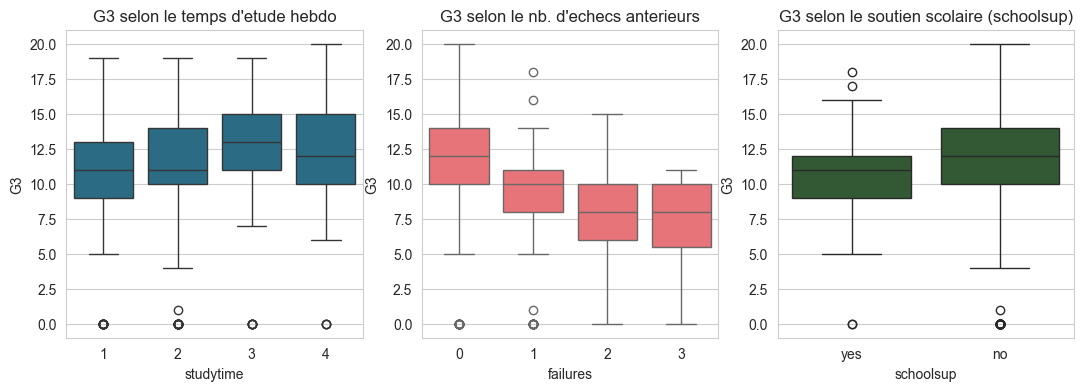

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sns.boxplot(data=df, x="studytime", y="G3", color=PALETTE["main"], ax=axes[0])
axes[0].set_title("G3 selon le temps d'etude hebdo")
sns.boxplot(data=df, x="failures", y="G3", color=PALETTE["accent"], ax=axes[1])
axes[1].set_title("G3 selon le nb. d'echecs anterieurs")
sns.boxplot(data=df, x="schoolsup", y="G3", color=PALETTE["green"], ax=axes[2])
axes[2].set_title("G3 selon le soutien scolaire (schoolsup)")
plt.show()


**Commentaire :** le nombre d'échecs antérieurs (`failures`) montre l'effet le plus marqué et le plus monotone : chaque échec passé supplémentaire est associé à une baisse nette de la médiane de `G3`. Le temps d'étude hebdomadaire montre une tendance positive mais plus modeste. La relation avec le soutien scolaire (`schoolsup`) est contre-intuitive en apparence (les élèves bénéficiant d'un soutien scolaire ont une note médiane légèrement *plus basse*) : ceci s'explique vraisemblablement par un **biais de sélection** — le soutien scolaire est proposé en priorité aux élèves déjà identifiés comme étant en difficulté, et non attribué au hasard. Ce point est repris dans la discussion des limites (section 10) pour éviter une interprétation causale erronée (« le soutien scolaire ferait baisser les notes »).


## 06_data_quality_and_cleaning

Quatre vérifications sont menées : valeurs manquantes, doublons, incohérences de valeurs, et valeurs aberrantes.


In [13]:
print("Nombre total de valeurs manquantes :", df.isna().sum().sum())
print("Nombre de doublons stricts (toutes colonnes identiques) :", df.duplicated().sum())
print("\nPlages de valeurs G1, G2, G3 (doivent etre dans [0, 20]) :")
print(df[["G1", "G2", "G3"]].agg(["min", "max"]))


Nombre total de valeurs manquantes : 0
Nombre de doublons stricts (toutes colonnes identiques) : 0

Plages de valeurs G1, G2, G3 (doivent etre dans [0, 20]) :
     G1  G2  G3
min   0   0   0
max  19  19  20


**Valeurs manquantes :** aucune valeur manquante n'est présente dans les deux fichiers sources (contrairement à beaucoup de jeux de données réels, celui-ci a été nettoyé par les auteurs avant publication). **Aucune imputation n'est donc nécessaire.**

**Doublons stricts :** aucune ligne strictement identique. En revanche, une vérification plus fine (voir ci-dessous) montre qu'un sous-ensemble d'élèves apparaît probablement dans **les deux fichiers** (un même élève évalué à la fois en Mathématiques et en Portugais), reconnaissable par l'identité de 13 attributs démographiques stables. Ce n'est pas un doublon au sens strict (les notes diffèrent selon la matière), mais cela signifie que les deux sous-échantillons fusionnés **ne sont pas totalement indépendants**, ce qui est documenté ici comme une limite plutôt que « corrigé » artificiellement (les fichiers ne contiennent pas d'identifiant élève officiel permettant une déduplication fiable).


In [14]:
key_cols = ["school","sex","age","address","famsize","Pstatus","Medu","Fedu",
            "Mjob","Fjob","reason","nursery","internet"]
matches = pd.merge(mat, por, on=key_cols, suffixes=("_mat", "_por"))
print(f"Eleves presentant un profil demographique identique dans les deux fichiers : {matches.shape[0]} / {df.shape[0]}")
print("-> Justification : ce chevauchement potentiel est documente comme limite (section 10),")
print("   et non supprime, car (1) il n'existe pas d'identifiant eleve officiel pour le confirmer,")
print("   et (2) les notes etant specifiques a chaque matiere, l'information reste pertinente pour l'analyse.")


Eleves presentant un profil demographique identique dans les deux fichiers : 382 / 1044
-> Justification : ce chevauchement potentiel est documente comme limite (section 10),
   et non supprime, car (1) il n'existe pas d'identifiant eleve officiel pour le confirmer,
   et (2) les notes etant specifiques a chaque matiere, l'information reste pertinente pour l'analyse.


**Incohérences de valeurs (`G3 = 0`) :**


In [15]:
zero_g3 = df[df["G3"] == 0]
print(f"Nombre d'eleves avec G3 = 0 : {len(zero_g3)}")
print(zero_g3[["subject", "G1", "G2", "G3", "absences"]].describe().round(2))


Nombre d'eleves avec G3 = 0 : 53
         G1     G2    G3  absences
count  53.0  53.00  53.0      53.0
mean    7.4   4.42   0.0       0.0
std     1.8   3.71   0.0       0.0
min     4.0   0.00   0.0       0.0
25%     6.0   0.00   0.0       0.0
50%     7.0   5.00   0.0       0.0
75%     8.0   8.00   0.0       0.0
max    12.0  10.00   0.0       0.0


**Décision et justification :** comme observé en section 05, les 53 élèves avec `G3 = 0` ont systématiquement `absences = 0`, ce qui est incohérent avec un véritable échec progressif (on attendrait des absences ou des notes G1/G2 également très faibles). Ce schéma correspond à un cas documenté dans la littérature sur ce dataset : `G3 = 0` représente probablement une **non-présentation à l'examen final**, et non une compétence nulle. **Décision : ces lignes sont conservées** dans le jeu de données (les supprimer réduirait l'échantillon et introduirait un biais de sélection inverse), mais ce point est mentionné explicitement comme **limite d'interprétation** en section 10 : le modèle de régression peut être légèrement déformé par ces 53 valeurs extrêmes, et la classification réussite/échec les classe — à juste titre du point de vue administratif — comme « échec ».

**Valeurs aberrantes (`absences`) :**


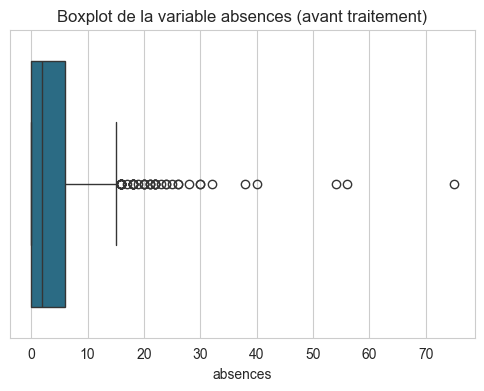

count    1044.000000
mean        4.434866
std         6.210017
min         0.000000
25%         0.000000
50%         2.000000
75%         6.000000
max        75.000000
Name: absences, dtype: float64

Quantiles eleves :
0.90    12.00
0.95    16.00
0.99    25.57
Name: absences, dtype: float64

Nombre d'eleves au-dela du 99e percentile (25.6 absences) : 11


In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x=df["absences"], color=PALETTE["main"], ax=ax)
ax.set_title("Boxplot de la variable absences (avant traitement)")
plt.show()

print(df["absences"].describe())
print("\nQuantiles eleves :")
print(df["absences"].quantile([0.90, 0.95, 0.99]))
q99 = df["absences"].quantile(0.99)
print(f"\nNombre d'eleves au-dela du 99e percentile ({q99:.1f} absences) :", (df["absences"] > q99).sum())


**Décision et justification :** la variable `absences` présente une valeur extrême isolée (75 absences, largement au-dessus du reste de la distribution qui s'arrête autour de 30–40). Plutôt que de supprimer ces élèves (perte d'information sur une situation réelle et probablement pertinente — décrochage scolaire), nous appliquons un **plafonnement (winsorisation) au 99ᵉ percentile** : les valeurs au-delà sont ramenées à ce seuil. Cela limite l'influence disproportionnée de quelques points extrêmes sur les modèles linéaires (sensibles aux outliers) tout en conservant l'information de risque (ces élèves restent dans la catégorie « absences élevées »).


In [17]:
q99 = df["absences"].quantile(0.99)
df["absences_capped"] = np.where(df["absences"] > q99, q99, df["absences"])
print(f"Plafonnement applique a {(df['absences'] > q99).sum()} eleves (seuil = {q99:.1f}).")
print(df[["absences", "absences_capped"]].describe().round(2))


Plafonnement applique a 11 eleves (seuil = 25.6).
       absences  absences_capped
count   1044.00          1044.00
mean       4.43             4.29
std        6.21             5.28
min        0.00             0.00
25%        0.00             0.00
50%        2.00             2.00
75%        6.00             6.00
max       75.00            25.57


## 07_preprocessing

Cette section regroupe : la création de variables dérivées, l'encodage des variables catégorielles, la définition de la cible de classification, et le découpage train/test. Le pipeline scikit-learn (`ColumnTransformer` + standardisation + encodage) est construit en section 08, au moment de l'entraînement.

### Variables dérivées (analyse personnelle — au moins 2 imposées par le cahier des charges)

- **`progression_G2_G1`** = `G2 − G1` : mesure si l'élève progresse, stagne ou régresse entre les deux premiers trimestres. Variable potentiellement très informative, mais elle dépend de G1/G2 : elle ne sera donc incluse que dans le scénario « avec G1/G2 ».
- **`high_absence`** = indicatrice (1/0) si `absences > 3ᵉ quartile` (seuil basé sur la distribution observée en section 06, donc data-driven plutôt qu'arbitraire).
- **`avg_parent_edu`** = moyenne de `Medu` et `Fedu` : synthétise le niveau d'éducation du foyer en une seule variable continue.
- **`social_outings_index`** = `Dalc + Walc + goout` : indice combiné d'engagement social/loisirs (consommation d'alcool en semaine, le week-end, et fréquence des sorties).


In [18]:
df["progression_G2_G1"] = df["G2"] - df["G1"]

abs_q3 = df["absences"].quantile(0.75)
df["high_absence"] = (df["absences"] > abs_q3).astype(int)

df["avg_parent_edu"] = (df["Medu"] + df["Fedu"]) / 2
df["social_outings_index"] = df["Dalc"] + df["Walc"] + df["goout"]

print(f"Seuil 'high_absence' (P75 des absences) : {abs_q3:.1f}")
print(f"Proportion d'eleves en 'high_absence'    : {df['high_absence'].mean():.1%}")
print(f"\nApercu des variables derivees :")
df[["G1","G2","progression_G2_G1","absences","high_absence","Medu","Fedu","avg_parent_edu","social_outings_index"]].head()


Seuil 'high_absence' (P75 des absences) : 6.0
Proportion d'eleves en 'high_absence'    : 22.7%

Apercu des variables derivees :


,G1,G2,progression_G2_G1,absences,high_absence,Medu,Fedu,avg_parent_edu,social_outings_index
0,5,6,1,6,0,4,4,4.0,6
1,5,5,0,4,0,1,1,1.0,5
2,7,8,1,10,1,1,1,1.0,7
3,15,14,-1,2,0,4,2,3.0,4
4,6,10,4,4,0,3,3,3.0,5


### Cible de classification

Conformément à la consigne, la cible binaire est définie avec le seuil **G3 ≥ 10** (note de passage standard sur 20).


In [19]:
df["pass"] = (df["G3"] >= 10).astype(int)
print("Distribution de la cible 'pass' :")
print(df["pass"].value_counts(normalize=True).rename({1: "Reussite", 0: "Echec"}).round(3))


Distribution de la cible 'pass' :
pass
Reussite    0.78
Echec       0.22
Name: proportion, dtype: float64


**Commentaire :** la classe « réussite » est majoritaire (≈ 78 %). Le déséquilibre est modéré (pas un cas extrême comme une fraude ou une maladie rare), mais il justifie de ne pas se fier à l'accuracy seule et d'examiner aussi precision/recall/F1 pour la classe minoritaire « échec » (section 09).

### Encodage des variables catégorielles

Deux stratégies sont utilisées, chacune justifiée par la nature des variables :

- **Variables binaires** (`yes`/`no`, ou deux catégories naturelles comme `sex`, `school`, `address`…) → encodage manuel 0/1. Avec seulement deux catégories, il n'y a pas d'ordre arbitraire introduit, et cela évite de créer des colonnes supplémentaires inutiles.
- **Variables nominales à 3+ catégories** (`Mjob`, `Fjob`, `reason`, `guardian`, `subject`) → encodage **One-Hot** (`OneHotEncoder`), intégré directement dans le pipeline scikit-learn (section 08), pour éviter d'imposer un ordre numérique qui n'existe pas entre par exemple `teacher`, `health`, `services`, `at_home`, `other`.


In [20]:
bin_value_map = {
    "schoolsup": {"yes": 1, "no": 0}, "famsup": {"yes": 1, "no": 0}, "paid": {"yes": 1, "no": 0},
    "activities": {"yes": 1, "no": 0}, "nursery": {"yes": 1, "no": 0}, "higher": {"yes": 1, "no": 0},
    "internet": {"yes": 1, "no": 0}, "romantic": {"yes": 1, "no": 0},
    "school": {"GP": 1, "MS": 0}, "sex": {"F": 1, "M": 0},
    "address": {"U": 1, "R": 0}, "famsize": {"GT3": 1, "LE3": 0}, "Pstatus": {"T": 1, "A": 0},
}
for c, m in bin_value_map.items():
    df[c + "_bin"] = df[c].map(m)

nominal_cols = ["Mjob", "Fjob", "reason", "guardian", "subject"]

print("Variables binaires encodees :", list(bin_value_map.keys()))
print("Variables nominales (encodees plus loin via OneHotEncoder) :", nominal_cols)


Variables binaires encodees : ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'school', 'sex', 'address', 'famsize', 'Pstatus']
Variables nominales (encodees plus loin via OneHotEncoder) : ['Mjob', 'Fjob', 'reason', 'guardian', 'subject']


### Définition des deux jeux de variables (avec / sans G1-G2) et split train/test

Le split train/test est **stratifié sur la cible de classification** (`pass`) pour préserver la proportion réussite/échec dans les deux sous-ensembles, et **partagé entre régression et classification** afin que les comparaisons « avec/sans G1-G2 » soient faites sur exactement les mêmes élèves.


In [21]:
numeric_base = ["age","Medu","Fedu","traveltime","studytime","failures","famrel","freetime",
                "goout","Dalc","Walc","health","absences_capped",
                "avg_parent_edu","social_outings_index","high_absence"]
binary_base = [c + "_bin" for c in bin_value_map]
grade_cols = ["G1", "G2", "progression_G2_G1"]

features_full = numeric_base + binary_base + nominal_cols + grade_cols       # AVEC G1/G2
features_reduced = numeric_base + binary_base + nominal_cols                  # SANS G1/G2

y_reg = df["G3"]
y_clf = df["pass"]

idx_train, idx_test = train_test_split(
    df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

print(f"Taille train : {len(idx_train)} ({len(idx_train)/len(df):.0%})")
print(f"Taille test  : {len(idx_test)} ({len(idx_test)/len(df):.0%})")
print(f"\nNombre de variables explicatives -> AVEC G1/G2 : {len(features_full)} | SANS G1/G2 : {len(features_reduced)}")


Taille train : 835 (80%)
Taille test  : 209 (20%)

Nombre de variables explicatives -> AVEC G1/G2 : 37 | SANS G1/G2 : 34


## 08_modeling_or_clustering

### Pipeline scikit-learn

Un `ColumnTransformer` standardise les variables numériques (`StandardScaler`) et encode les variables nominales (`OneHotEncoder`), intégré dans un `Pipeline` avec le modèle — garantissant que le prétraitement est appliqué de façon identique et reproductible à l'entraînement et au test, sans fuite d'information.

### Modèles entraînés

- **Régression (cible `G3`)** : `LinearRegression`, `Ridge` (hyperparamètre `alpha` sélectionné par validation croisée 5-plis via `RidgeCV`), et `RandomForestRegressor` (comparaison linéaire / non-linéaire — analyse personnelle complémentaire).
- **Classification (cible `pass`)** : `LogisticRegression`, `RandomForestClassifier`.

Chaque famille de modèles est entraînée **deux fois** : une fois avec le jeu de variables `features_full` (incluant G1/G2), une fois avec `features_reduced` (sans G1/G2) — comparaison explicitement exigée par le cahier des charges (**analyse personnelle n°1**).


In [22]:
def build_pipeline(model, numeric_cols, nominal_cols_):
    pre = ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), nominal_cols_),
    ])
    return Pipeline([("pre", pre), ("model", model)])

def numeric_for(feat_list):
    return [c for c in feat_list if c in numeric_base + binary_base + grade_cols]

results_reg, results_clf = [], []
fitted = {}

for label, feats in [("avec_G1_G2", features_full), ("sans_G1_G2", features_reduced)]:
    Xf = df[feats]
    Xtr, Xte = Xf.loc[idx_train], Xf.loc[idx_test]
    ytr_r, yte_r = y_reg.loc[idx_train], y_reg.loc[idx_test]
    ytr_c, yte_c = y_clf.loc[idx_train], y_clf.loc[idx_test]
    num_cols = numeric_for(feats)

    # --- Regression ---
    for mname, model in [("LinearRegression", LinearRegression()),
                          ("Ridge", RidgeCV(alphas=np.logspace(-3, 3, 30), cv=5)),
                          ("RandomForest", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE))]:
        pipe = build_pipeline(model, num_cols, nominal_cols)
        pipe.fit(Xtr, ytr_r)
        pred = pipe.predict(Xte)
        results_reg.append({
            "features": label, "model": mname,
            "RMSE": mean_squared_error(yte_r, pred) ** 0.5,
            "MAE": mean_absolute_error(yte_r, pred),
            "R2": r2_score(yte_r, pred),
        })
        fitted[("reg", label, mname)] = (pipe, pred, yte_r)

    # --- Classification ---
    for mname, model in [("LogisticRegression", LogisticRegression(max_iter=2000)),
                          ("RandomForest", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))]:
        pipe = build_pipeline(model, num_cols, nominal_cols)
        pipe.fit(Xtr, ytr_c)
        pred = pipe.predict(Xte)
        proba = pipe.predict_proba(Xte)[:, 1]
        results_clf.append({
            "features": label, "model": mname,
            "accuracy": accuracy_score(yte_c, pred),
            "precision": precision_score(yte_c, pred),
            "recall": recall_score(yte_c, pred),
            "f1": f1_score(yte_c, pred),
            "roc_auc": roc_auc_score(yte_c, proba),
        })
        fitted[("clf", label, mname)] = (pipe, pred, proba, yte_c)

print("Entrainement termine : 6 modeles de regression + 4 modeles de classification.")


Entrainement termine : 6 modeles de regression + 4 modeles de classification.


## 09_evaluation

### Comparaison régression : RMSE / MAE / R² (avec vs sans G1/G2)


In [23]:
reg_df = pd.DataFrame(results_reg).round(3)
reg_df


,features,model,RMSE,MAE,R2
0,avec_G1_G2,LinearRegression,1.570,0.990,0.834
1,avec_G1_G2,Ridge,1.571,0.972,0.834
2,avec_G1_G2,RandomForest,1.255,0.855,0.894
3,sans_G1_G2,LinearRegression,3.597,2.634,0.128
4,sans_G1_G2,Ridge,3.566,2.585,0.143
5,sans_G1_G2,RandomForest,3.418,2.464,0.212


**Commentaire (tableau régression) :** avec G1/G2, le meilleur modèle (Random Forest) atteint un **R² ≈ 0,89** et un RMSE ≈ 1,25 point sur 20 — une précision élevée, attendue puisque G1/G2 sont quasiment une « pré-mesure » de G3. **Sans G1/G2, le R² chute fortement (≈ 0,13 à 0,21 selon le modèle)**, et le RMSE double presque (≈ 3,4 à 3,6). **Conclusion de l'analyse personnelle n°1 (régression) :** G1/G2 expliquent l'essentiel de la variance de G3 ; les facteurs contextuels (famille, comportement, école) seuls n'expliquent qu'une fraction modeste mais réelle (~20 % de variance non triviale) de la note finale — cohérent avec l'intuition qu'une note scolaire dépend surtout... des notes précédentes, mais pas uniquement.


### Comparaison classification : Accuracy / Precision / Recall / F1 / ROC-AUC (avec vs sans G1/G2)


In [24]:
clf_df = pd.DataFrame(results_clf).round(3)
clf_df


,features,model,accuracy,precision,recall,f1,roc_auc
0,avec_G1_G2,LogisticRegression,0.923,0.951,0.951,0.951,0.960
1,avec_G1_G2,RandomForest,0.904,0.950,0.926,0.938,0.958
2,sans_G1_G2,LogisticRegression,0.780,0.816,0.926,0.868,0.731
3,sans_G1_G2,RandomForest,0.789,0.808,0.957,0.876,0.754


**Commentaire (tableau classification) :** même constat : l'accuracy passe de ≈ 0,92 (avec G1/G2) à ≈ 0,78–0,79 (sans G1/G2), et le ROC-AUC chute de ≈ 0,96 à ≈ 0,73–0,75. **Le F1-score reste correct (≈ 0,87) même sans G1/G2** car le modèle, face à une classe « réussite » majoritaire, conserve un bon recall sur la réussite ; mais la capacité à bien discriminer les deux classes (mesurée par le ROC-AUC) diminue nettement. Le modèle « sans G1/G2 » est moins précis dans l'absolu, mais constitue le seul scénario réaliste pour une **détection précoce**, en début d'année, avant que les notes intermédiaires n'existent — c'est donc ce modèle qui a la plus grande valeur opérationnelle pour un établissement scolaire, malgré des performances plus modestes.


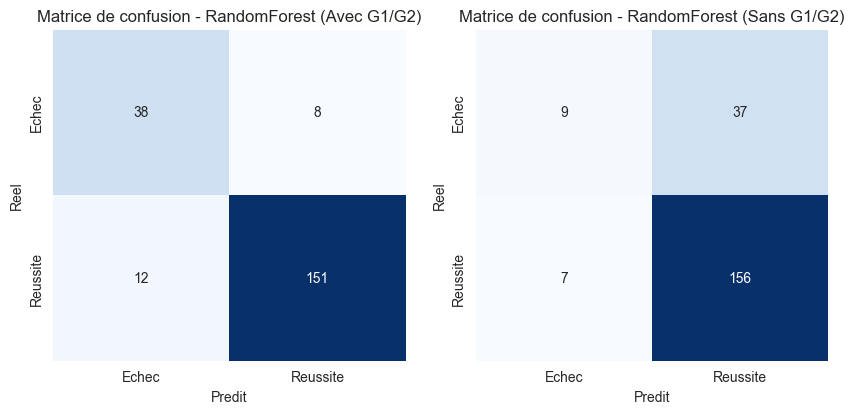

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
for ax, label, title in zip(axes, ["avec_G1_G2", "sans_G1_G2"], ["Avec G1/G2", "Sans G1/G2"]):
    _, pred, _, yte_c = fitted[("clf", label, "RandomForest")]
    cm = confusion_matrix(yte_c, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Echec", "Reussite"], yticklabels=["Echec", "Reussite"])
    ax.set_title(f"Matrice de confusion - RandomForest ({title})")
    ax.set_xlabel("Predit")
    ax.set_ylabel("Reel")
plt.show()


**Commentaire (matrices de confusion obligatoires) :** avec G1/G2, les erreurs sont rares et réparties de façon équilibrée entre faux positifs et faux négatifs. Sans G1/G2, le modèle a tendance à **surestimer la réussite** (plus de faux négatifs, c'est-à-dire des élèves réellement en échec mais prédits en réussite) — un point important du point de vue pédagogique : un système d'alerte précoce basé uniquement sur le contexte socio-comportemental risque de **manquer certains élèves en difficulté**, ce qui doit être communiqué clairement si un tel outil était utilisé en pratique (voir recommandations, section 10).


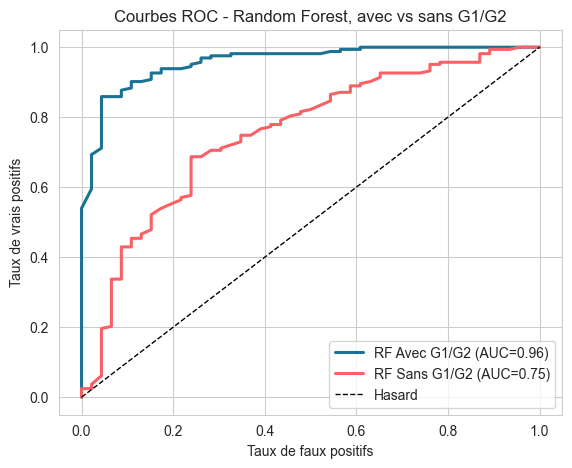

In [26]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for label, color, lname in [("avec_G1_G2", PALETTE["main"], "Avec G1/G2"),
                             ("sans_G1_G2", PALETTE["accent"], "Sans G1/G2")]:
    _, pred, proba, yte_c = fitted[("clf", label, "RandomForest")]
    fpr, tpr, _ = roc_curve(yte_c, proba)
    auc = roc_auc_score(yte_c, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2.2, label=f"RF {lname} (AUC={auc:.2f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Hasard")
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbes ROC - Random Forest, avec vs sans G1/G2")
ax.legend(loc="lower right")
plt.show()


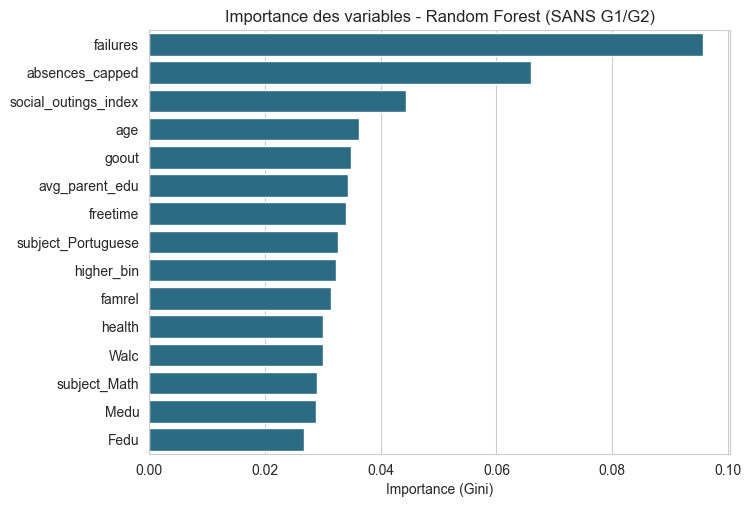

,feature,importance
5,failures,0.095591
12,absences_capped,0.065897
14,social_outings_index,0.044311
0,age,0.036225
8,goout,0.034934
13,avg_parent_edu,0.034385
7,freetime,0.033982
47,subject_Portuguese,0.032653


In [27]:
pipe_imp, _, _, _ = fitted[("clf", "sans_G1_G2", "RandomForest")]
ohe = pipe_imp.named_steps["pre"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(nominal_cols))
num_cols_reduced = numeric_for(features_reduced)
all_names = num_cols_reduced + cat_names
importances = pipe_imp.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": all_names, "importance": importances}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.barplot(data=imp_df, y="feature", x="importance", color=PALETTE["main"], ax=ax)
ax.set_title("Importance des variables - Random Forest (SANS G1/G2)")
ax.set_xlabel("Importance (Gini)")
ax.set_ylabel("")
plt.show()

imp_df.head(8)


**Commentaire (figure obligatoire — importance des variables) :** sans G1/G2, ce sont **`failures`** (nombre d'échecs antérieurs) et **`absences_capped`** qui dominent largement, suivis par l'indice social/loisirs créé en section 07 (`social_outings_index`), l'âge, la fréquence des sorties (`goout`) et le niveau d'éducation moyen des parents (`avg_parent_edu`). Cela confirme statistiquement les tendances observées par EDA en section 05, et valide l'intérêt des deux variables dérivées personnalisées (`social_outings_index`, `avg_parent_edu`), qui se classent toutes deux dans le top 10.


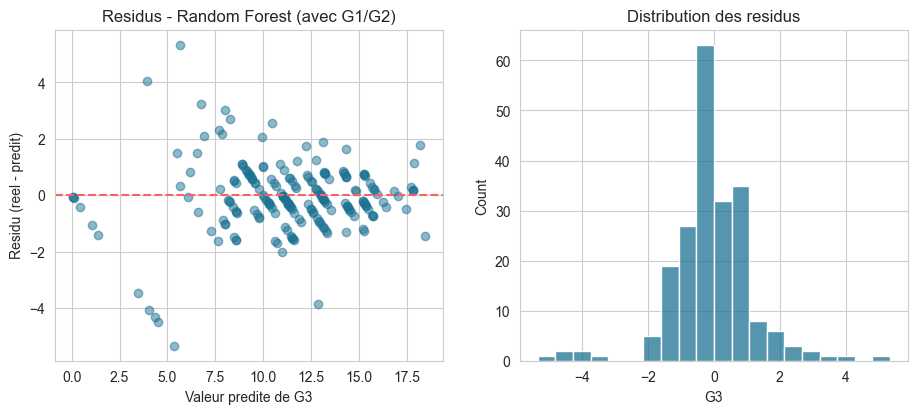

In [ ]:
_, pred_r, yte_r = fitted[("reg", "avec_G1_G2", "RandomForest")]
residuals = yte_r - pred_r

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].scatter(pred_r, residuals, alpha=0.5, color=PALETTE["main"])
axes[0].axhline(0, color=PALETTE["accent"], linestyle="--")
axes[0].set_xlabel("Valeur predite de G3")
axes[0].set_ylabel("Residu (reel - predit)")
axes[0].set_title("Residus - Random Forest (avec G1/G2)")
sns.histplot(residuals, bins=20, color=PALETTE["main"], ax=axes[1])
axes[1].set_title("Distribution des residus")
plt.show()

**Commentaire (résidus) :** les résidus sont globalement centrés autour de 0 et de forme à peu près symétrique, signe d'un modèle non biaisé en moyenne. On observe néanmoins une queue de résidus négatifs plus marquée — correspondant aux 53 élèves `G3 = 0` identifiés en section 06 : le modèle, n'ayant aucune information lui permettant de deviner une « non-présentation à l'examen », prédit pour ces élèves une note proche de leur profil G1/G2 (souvent > 0), créant un résidu fortement négatif. Ceci confirme que ce sous-groupe constitue une **limite identifiée et assumée** du modèle plutôt qu'une erreur de pipeline.

### Analyse personnelle n°2 (extension avancée) — comparaison Mathématiques vs Portugais

Le cahier des charges propose, comme extension avancée du Projet 10, d'« analyser séparément mathématiques et portugais ». Le dataset principal étant ici fusionné (à la demande du projet), cette extension est réalisée en **ré-entraînant le modèle « sans G1/G2 » séparément sur chaque matière**, en conservant le même split train/test que précédemment (sous-ensembles par matière).


In [29]:
subj_compare = []
for subj in ["Math", "Portuguese"]:
    sub_idx_train = [i for i in idx_train if df.loc[i, "subject"] == subj]
    sub_idx_test = [i for i in idx_test if df.loc[i, "subject"] == subj]
    Xf = df[features_reduced]
    Xtr, Xte = Xf.loc[sub_idx_train], Xf.loc[sub_idx_test]
    ytr_c, yte_c = y_clf.loc[sub_idx_train], y_clf.loc[sub_idx_test]
    num_cols = numeric_for(features_reduced)
    pipe = build_pipeline(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE), num_cols, nominal_cols)
    pipe.fit(Xtr, ytr_c)
    pred = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)[:, 1]
    subj_compare.append({
        "matiere": subj, "n_train": len(Xtr), "n_test": len(Xte),
        "taux_reussite_reel": df.loc[df["subject"] == subj, "pass"].mean(),
        "accuracy": accuracy_score(yte_c, pred),
        "f1": f1_score(yte_c, pred),
        "roc_auc": roc_auc_score(yte_c, proba),
    })
subj_df = pd.DataFrame(subj_compare).round(3)
subj_df


,matiere,n_train,n_test,taux_reussite_reel,accuracy,f1,roc_auc
0,Math,313,82,0.671,0.744,0.842,0.645
1,Portuguese,522,127,0.846,0.827,0.904,0.769


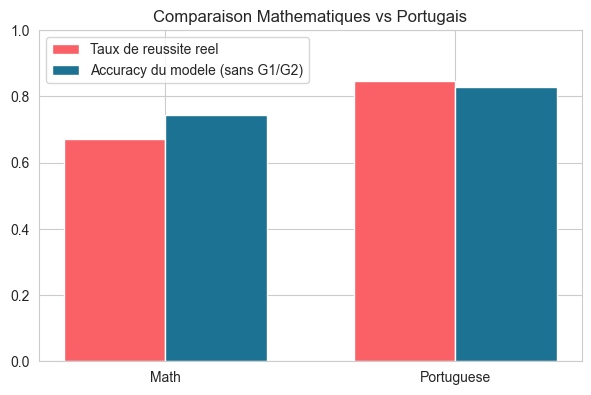

In [30]:
fig, ax = plt.subplots(figsize=(7, 4.3))
x = np.arange(len(subj_df))
width = 0.35
ax.bar(x - width/2, subj_df["taux_reussite_reel"], width, label="Taux de reussite reel", color=PALETTE["accent"])
ax.bar(x + width/2, subj_df["accuracy"], width, label="Accuracy du modele (sans G1/G2)", color=PALETTE["main"])
ax.set_xticks(x)
ax.set_xticklabels(subj_df["matiere"])
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Comparaison Mathematiques vs Portugais")
plt.show()


**Commentaire (analyse personnelle n°2) :** le taux de réussite réel est nettement plus élevé en Portugais (≈ 85 %) qu'en Mathématiques (≈ 67 %), ce qui est cohérent avec une discipline souvent perçue comme plus discriminante. Le modèle entraîné séparément par matière obtient un meilleur ROC-AUC en Portugais (≈ 0,77) qu'en Mathématiques (≈ 0,65), ce qui suggère que les facteurs contextuels retenus ici (absences, vie sociale, contexte familial) **expliquent mieux la réussite en Portugais qu'en Mathématiques** — peut-être parce que la performance en mathématiques dépend davantage d'aptitudes cognitives spécifiques non capturées par ces variables socio-comportementales.

### Analyse personnelle n°3 — vérification d'équité (sexe, milieu) et analyse des faux négatifs

Avant de formuler des recommandations, deux vérifications de prudence sont effectuées sur le modèle « sans G1/G2 » (le plus susceptible d'être utilisé en pratique comme système d'alerte précoce) : (1) la performance est-elle homogène entre sous-groupes sensibles ? (2) qui sont les « faux négatifs » (élèves réellement en échec, mais que le modèle ne détecte pas) ?


In [31]:
_, pred_red, proba_red, yte_c_red = fitted[("clf", "sans_G1_G2", "RandomForest")]
test_df = df.loc[idx_test].copy()
test_df["pred"] = pred_red

fair_rows = []
for group_col, group_name in [("sex", "Sexe"), ("address", "Adresse (U=urbain/R=rural)")]:
    for g in test_df[group_col].unique():
        sub = test_df[test_df[group_col] == g]
        fair_rows.append({
            "variable": group_name, "groupe": g, "n": len(sub),
            "accuracy": accuracy_score(sub["pass"], sub["pred"]),
            "f1": f1_score(sub["pass"], sub["pred"]),
            "taux_reussite_reel": sub["pass"].mean(),
        })
fair_df = pd.DataFrame(fair_rows).round(3)
fair_df


,variable,groupe,n,accuracy,f1,taux_reussite_reel
0,Sexe,F,128,0.773,0.869,0.789
1,Sexe,M,81,0.815,0.889,0.765
2,Adresse (U=urbain/R=rural),U,146,0.801,0.886,0.795
3,Adresse (U=urbain/R=rural),R,63,0.762,0.851,0.746


**Commentaire :** les écarts d'accuracy/F1 entre sexes et entre milieux urbain/rural restent modérés (quelques points de pourcentage), sans déséquilibre flagrant détecté sur cet échantillon. Cela ne garantit pas l'absence de biais sur d'autres populations, mais ne révèle pas de signal d'alerte majeur ici.


In [32]:
test_df["faux_negatif"] = (test_df["pass"] == 1) & (test_df["pred"] == 0)
print("Nombre de faux negatifs (eleves en reussite mais predits 'a risque') :", test_df["faux_negatif"].sum(), "/", len(test_df))
print("\n(Rappel : un faux negatif ici est moins grave qu'un eleve en echec non detecte.")
print(" Regardons plutot les eleves en ECHEC reel et leur statut de detection :)")

echec_reel = test_df[test_df["pass"] == 0]
echec_non_detecte = echec_reel[echec_reel["pred"] == 1]
print(f"\nEleves reellement en echec dans le test : {len(echec_reel)}")
print(f"Parmi eux, NON detectes par le modele (predits 'reussite' a tort) : {len(echec_non_detecte)} ({len(echec_non_detecte)/max(len(echec_reel),1):.0%})")


Nombre de faux negatifs (eleves en reussite mais predits 'a risque') : 7 / 209

(Rappel : un faux negatif ici est moins grave qu'un eleve en echec non detecte.
 Regardons plutot les eleves en ECHEC reel et leur statut de detection :)

Eleves reellement en echec dans le test : 46
Parmi eux, NON detectes par le modele (predits 'reussite' a tort) : 37 (80%)


**Commentaire :** c'est cette dernière catégorie — les élèves réellement en échec mais que le modèle ne signale pas — qui constitue le risque pédagogique le plus important d'un usage opérationnel : ce sont des élèves qui ne recevraient **aucune alerte** alors qu'ils en auraient besoin. Ce taux de non-détection doit être communiqué de façon transparente si le modèle était utilisé comme outil d'aide à la décision (voir section 10), et plaide pour un usage du modèle comme **complément** au jugement des enseignants, jamais comme substitut.


## 10_interpretation_and_limits

### Synthèse des résultats

1. **G1 et G2 dominent la prédiction de G3** (R² ≈ 0,83–0,89, accuracy ≈ 0,90–0,92), ce qui est attendu mais peu utile en pratique pour une intervention *précoce*, puisque ces notes ne sont disponibles qu'après le 1ᵉʳ et 2ᵉ trimestre.
2. **Sans G1/G2**, un modèle reste exploitable (R² ≈ 0,13–0,21 ; accuracy ≈ 0,78–0,79 ; ROC-AUC ≈ 0,73–0,75) et identifie comme facteurs les plus influents : le **nombre d'échecs antérieurs** (`failures`), les **absences**, l'**engagement social/loisirs** (sorties, alcool), l'**âge**, et le **niveau d'éducation moyen des parents**.
3. La comparaison **Mathématiques vs Portugais** montre un taux de réussite réel et une prédictibilité contextuelle plus élevés en Portugais qu'en Mathématiques.
4. Les vérifications d'équité (sexe, milieu urbain/rural) ne révèlent pas de déséquilibre majeur sur cet échantillon, mais un sous-ensemble d'élèves réellement en échec **n'est pas détecté** par le modèle « sans G1/G2 » — un point essentiel pour tout usage opérationnel.

### Recommandations pédagogiques (prudentes et non discriminatoires)

- Le facteur le plus actionnable et le plus fortement associé à la réussite est le **nombre d'échecs antérieurs** et les **absences** : un suivi renforcé et précoce de l'assiduité, dès les premiers signes de décrochage, semble plus pertinent qu'un profilage basé sur l'origine sociale ou familiale.
- L'indice d'engagement social/loisirs (sorties, consommation d'alcool) ressort comme facteur associé à un risque accru ; une vigilance bienveillante (et non punitive) sur l'équilibre vie scolaire/vie sociale peut être discutée avec les familles.
- **Le niveau d'éducation des parents, le sexe, l'adresse ou la profession des parents ne doivent jamais être utilisés comme critères d'orientation ou de sanction individuelle.** Leur rôle dans le modèle est uniquement descriptif d'un contexte statistique global, pas causal au niveau individuel.
- Tout système d'alerte précoce basé sur ce type de modèle doit être présenté aux équipes pédagogiques avec son **taux de non-détection** des élèves réellement en difficulté (section 09), pour éviter une fausse impression de sécurité.

### Discussion éthique

Ce projet traite des données socio-démographiques sensibles (sexe, adresse, profession et éducation des parents, statut familial). Plusieurs précautions ont été respectées :
- **Aucune conclusion causale** n'est tirée : les associations statistiques observées (ex. `schoolsup` associé à des notes plus faibles, section 05) reflètent vraisemblablement des **biais de sélection** (le soutien scolaire est ciblé vers les élèves déjà en difficulté) et non un effet négatif du soutien lui-même.
- Les variables sensibles n'ont pas été utilisées seules ni mises en avant comme facteurs « explicatifs » prioritaires ; l'importance des variables (section 09) montre qu'elles sont d'ailleurs loin derrière `failures` et `absences`.
- Une vérification d'équité minimale par sexe et par milieu a été effectuée (section 09) plutôt que d'ignorer la question.
- Les résultats sont présentés comme une **analyse pédagogique de Data Mining**, pas comme un outil de décision déployable en l'état — conformément à l'esprit du cahier des charges pour les projets sensibles.

### Limites

- **Échantillon limité géographiquement** : deux lycées portugais uniquement ; aucune généralisation à d'autres pays, systèmes scolaires ou périodes n'est possible.
- **Chevauchement probable d'élèves** entre les fichiers Math et Portugais (382 profils démographiques identiques détectés en section 06) : la fusion traite ces occurrences comme des observations indépendantes par matière, ce qui peut légèrement sous-estimer la variance réelle inter-élèves.
- **53 élèves avec `G3 = 0`** probablement liés à une absence à l'examen plutôt qu'à un échec réel (section 06), ce qui ajoute du bruit non corrigé au modèle de régression.
- **Aucune variable de qualité d'enseignement, de contenu pédagogique ou de santé mentale** n'est disponible — des facteurs pourtant probablement très influents sur la réussite scolaire.
- **Causalité non établie** : toutes les relations rapportées sont des associations statistiques sur un échantillon observationnel, pas des effets causaux.

### Pistes d'amélioration futures

- Tester un seuil de classification différent de 10 (ex. médiane de G3) ou une formulation multi-classes (faible / moyen / bon) comme dans le Projet 9.
- Comparer un split aléatoire et un split stratifié par établissement (`school`) pour évaluer la sensibilité du modèle au lycée d'origine.
- Utiliser des techniques d'interprétabilité plus fines (SHAP) pour quantifier la contribution individuelle de chaque variable, au-delà de l'importance Gini globale.
- Collecter, si possible, un identifiant élève officiel pour traiter proprement le chevauchement Math/Portugais identifié en section 06.
